# Trabajo de Fin de Grado: Desarrollo y Evaluacion de un Metodo Cuantico de Seleccion de Caracteristicas

## Notebook 08 - Fase 8: Ejecucion QFS, Barrido beta y Control con Oraculo

Esta fase ejecuta el bloque cuantico sobre las matrices `I_i` y `R_ij` generadas por la Fase 5. El objetivo no es reinterpretar el banco clasico, sino construir los subconjuntos QFS que pasaran a la evaluacion final de la Fase 9. Se separan dos planos: el solver operativo QFS-NA con `alpha=0.5` fijo y barrido de `beta`, y el oraculo QUBO exacto que recorre `alpha` para auditar si el criterio teorico y el simulador analogico apuntan al mismo subconjunto.

## Importacion de Librerias

In [1]:
import importlib.util
import contextlib
import io
import json
import os
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Sites .* are too close")

## Definicion de Rutas y Parametros

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
if str(PROJECT_ROOT / "QFS_based_on_NA") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "QFS_based_on_NA"))

from phase6_modeling import pipeline as p6

QFS_DIR = PROJECT_ROOT / "QFS_based_on_NA"
TABLE_IN = PROJECT_ROOT / "results" / "tables" / "05_feature_selection"
TABLE_OUT = PROJECT_ROOT / "results" / "tables" / "08_quantum"
FIG_OUT = PROJECT_ROOT / "results" / "figures" / "08_quantum"
LOG_OUT = PROJECT_ROOT / "results" / "logs" / "08_quantum"
for folder in [TABLE_OUT, FIG_OUT, LOG_OUT]:
    folder.mkdir(parents=True, exist_ok=True)

spec = importlib.util.spec_from_file_location("qfs_aux", QFS_DIR / "QFS_Auxiliar_functions.py")
qfs = importlib.util.module_from_spec(spec)
assert spec and spec.loader
spec.loader.exec_module(qfs)

DATASETS = [
    "breast_cancer_wisconsin",
    "customer_churn",
    "madelon",
    "olive_oil_3class",
    "olive_oil_9class",
]
BETA_GRID = [round(x / 10, 1) for x in range(11)]
ALPHA_GRID = [round(x / 10, 1) for x in range(11)]
K_BY_DATASET = {
    "olive_oil_3class": 5,
    "olive_oil_9class": 5,
    "customer_churn": 10,
    "breast_cancer_wisconsin": 10,
    "madelon": 10,
}
PRESELECT_TO = {"breast_cancer_wisconsin": 20, "madelon": 20}

# El protocolo documentado hereda del solver y del paper 100 inicializaciones MDS
# independientes y hasta 100 iteraciones de busqueda robusta.
QFS_SHOTS = 10000
QFS_T = 4
QFS_MDS_MAX_ITER = 100
QFS_MDS_RUNS = 100
QFS_DIST_RATIOS = [1 / np.sqrt(2)]  # 1/sqrt(2): valor del paper, sin relajacion
FORCE_QFS = True

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Solver QFS cargado: {QFS_DIR / 'QFS_Auxiliar_functions.py'}")
print(f"Simulador Braket local disponible: {qfs.simulator is not None}")
print(f"Shots por ejecucion QFS-NA: {QFS_SHOTS}")
print(f"MDS robusto: max_iter={QFS_MDS_MAX_ITER}, n_mds_runs={QFS_MDS_RUNS}")

Proyecto: /home/gosacar/TFG - QFS Last Chance Claude
Solver QFS cargado: /home/gosacar/TFG - QFS Last Chance Claude/QFS_based_on_NA/QFS_Auxiliar_functions.py
Simulador Braket local disponible: True
Shots por ejecucion QFS-NA: 10000
MDS robusto: max_iter=100, n_mds_runs=100


La ejecucion usa `10000` shots y el MDS verificado del solver: `100` inicializaciones independientes y `100` iteraciones de busqueda robusta. La separacion minima entre atomos usa la fraccion del radio de bloqueo del paper, `1/sqrt(2)`, sin relajacion; un barrido de factibilidad confirmo que produce embebidos validos en los cinco datasets. No se modifican los `_OG.py`.

## 8.1 Pre-seleccion Hibrida

In [3]:
def cargar_qfs_inputs(dataset):
    vector = pd.read_csv(TABLE_IN / f"fs_qfs_mi_target_vector__{dataset}.csv")
    matrix = pd.read_csv(TABLE_IN / f"fs_qfs_pairwise_mi_matrix__{dataset}.csv", index_col=0)
    features = vector["feature"].tolist()
    if matrix.index.tolist() != features:
        matrix = matrix.loc[features, features]
    return features, vector["I_i"].to_numpy(dtype=float), matrix.to_numpy(dtype=float)


def cargar_preseleccion_mrmr(dataset, n_features=20):
    path = PROJECT_ROOT / "data" / "selected_features" / dataset / "mrmr_approx" / f"k_{n_features}" / "selected_features.csv"
    tabla = pd.read_csv(path)
    return tabla.sort_values("rank")["feature"].tolist()


def preparar_inputs_dataset(dataset):
    features, I_i, R_ij = cargar_qfs_inputs(dataset)
    preselector = "directo"
    original_n = len(features)
    if dataset in PRESELECT_TO:
        keep = cargar_preseleccion_mrmr(dataset, PRESELECT_TO[dataset])
        pos = [features.index(feature) for feature in keep]
        features = keep
        I_i = I_i[pos]
        R_ij = R_ij[np.ix_(pos, pos)]
        preselector = "mrmr_approx_k20"
    return {
        "dataset": dataset,
        "features": features,
        "I_i": I_i,
        "R_ij": R_ij,
        "original_n": original_n,
        "qfs_n": len(features),
        "preselector": preselector,
        "k_budget": K_BY_DATASET[dataset],
    }


inputs = {dataset: preparar_inputs_dataset(dataset) for dataset in DATASETS}
preseleccion = pd.DataFrame([
    {
        "dataset": ds,
        "original_n": info["original_n"],
        "qfs_n": info["qfs_n"],
        "k_budget": info["k_budget"],
        "preselector": info["preselector"],
        "features": "|".join(info["features"]),
    }
    for ds, info in inputs.items()
])
preseleccion.to_csv(TABLE_OUT / "qfs_preselection_summary.csv", index=False)
display(preseleccion)

,dataset,original_n,qfs_n,k_budget,preselector,features
0,breast_cancer_wisconsin,30,20,10,mrmr_approx_k20,concave_points_worst|smoothness_se|texture_wor...
1,customer_churn,15,15,10,directo,age|tenure|usage_frequency|support_calls|payme...
2,madelon,500,20,10,mrmr_approx_k20,feat_241|feat_43|feat_311|feat_154|feat_139|fe...
3,olive_oil_3class,8,8,5,directo,palmitoleic|stearic|oleic|linoleic|linolenic|a...
4,olive_oil_9class,8,8,5,directo,palmitoleic|stearic|oleic|linoleic|linolenic|a...


La preseleccion solo actua donde la envolvente del simulador supera 20 atomos: `breast_cancer_wisconsin` y `madelon` pasan por `mrmr_approx_k20`, el analogo voraz del compromiso relevancia-redundancia de QFS. `customer_churn` entra directo con 15 variables porque las 10 predictoras crudas se materializan como 15 columnas one-hot en el handoff de Fase 5.

## 8.2 Ejecucion Operativa QFS-NA con Barrido beta

In [4]:
def beta_label(beta):
    return f"{beta:.1f}".replace(".", "p")


def bitstring_to_features(bits, features):
    return [feature for bit, feature in zip(bits, features) if int(bit) == 1]


def topk_from_density(avg_density, k):
    order = np.argsort(np.asarray(avg_density, dtype=float))[::-1]
    bits = np.zeros(len(avg_density), dtype=int)
    bits[order[:k]] = 1
    return bits


def embedding_row(dataset, info, beta, ratio, min_radius, mds_dist, target_dist, positions, error_matrix):
    upper = np.triu_indices(len(info["features"]), k=1)
    return {
        "dataset": dataset,
        "beta": beta,
        "qfs_n": len(info["features"]),
        "k_budget": info["k_budget"],
        "mds_max_iter": QFS_MDS_MAX_ITER,
        "mds_runs": QFS_MDS_RUNS,
        "dist_ratio_rydberg": ratio,
        "min_radius": float(min_radius),
        "embedding_error_mean": float(np.mean(error_matrix[upper])),
        "embedding_error_std": float(np.std(error_matrix[upper])),
        "embedding_error_p95": float(np.quantile(error_matrix[upper], 0.95)),
        "target_distance_mean": float(np.mean(target_dist[upper])),
        "mds_distance_mean": float(np.mean(mds_dist[upper])),
        "positions_json": json.dumps([
            {"feature": feature, "x": float(x), "y": float(y)}
            for feature, (x, y) in zip(info["features"], np.asarray(positions))
        ], ensure_ascii=False),
    }


def run_operational_qfs(dataset, info, beta):
    out_path = TABLE_OUT / f"qfs_runs_{dataset}_{beta_label(beta)}.csv"
    if out_path.exists() and not FORCE_QFS:
        tabla = pd.read_csv(out_path)
        density = tabla.filter(regex=r"^density__").iloc[0].to_numpy(dtype=float)
        return tabla, density, None

    started = time.perf_counter()
    last_error = None
    chosen_ratio = None
    chosen_embedding = None
    original_arrange_atoms = qfs.arrange_atoms_robust_MDS
    for ratio in QFS_DIST_RATIOS:
        try:
            captured = {}

            def capture_arrangement(*args, **kwargs):
                result = original_arrange_atoms(*args, **kwargs)
                captured["result"] = result
                return result

            qfs.arrange_atoms_robust_MDS = capture_arrangement
            try:
                with contextlib.redirect_stdout(io.StringIO()):
                    costs, counts, bitstrings, avg_density = qfs.QFS_NA_Solver(
                        info["I_i"],
                        info["R_ij"],
                        info["features"],
                        f"{dataset}_beta_{beta_label(beta)}_r{str(ratio).replace('.', 'p')}",
                        E_dist_fraction=0.1,
                        shots=QFS_SHOTS,
                        t=QFS_T,
                        beta=beta,
                        mds_max_iter=QFS_MDS_MAX_ITER,
                        mds_runs=QFS_MDS_RUNS,
                        make_plots=False,
                        dist_ratio_rydberg=ratio,
                    )
            finally:
                qfs.arrange_atoms_robust_MDS = original_arrange_atoms
            chosen_ratio = ratio
            chosen_embedding = captured.get("result")
            break
        except ValueError as exc:
            qfs.arrange_atoms_robust_MDS = original_arrange_atoms
            last_error = exc
    if chosen_ratio is None:
        raise RuntimeError(f"{dataset} beta={beta}: no se encontro geometria valida") from last_error
    if chosen_embedding is None:
        raise RuntimeError(f"{dataset} beta={beta}: el solver no devolvio embebido MDS capturable")
    elapsed = time.perf_counter() - started
    density = np.asarray(avg_density, dtype=float)
    rows = []
    for cost, count, bits in zip(costs, counts, bitstrings):
        bits = np.asarray(bits, dtype=int)
        row = {
            "dataset": dataset,
            "beta": beta,
            "shots": QFS_SHOTS,
            "qfs_n": len(info["features"]),
            "k_budget": info["k_budget"],
            "elapsed_seconds": elapsed,
            "dist_ratio_rydberg": chosen_ratio,
            "cost_f": float(cost),
            "count": int(count),
            "bitstring": "".join(map(str, bits.tolist())),
            "selected_features": "|".join(bitstring_to_features(bits, info["features"])),
        }
        row.update({f"density__{feature}": float(value) for feature, value in zip(info["features"], density)})
        rows.append(row)
    tabla = pd.DataFrame(rows)
    tabla.to_csv(out_path, index=False)
    embedding = embedding_row(dataset, info, beta, chosen_ratio, *chosen_embedding)
    print(
        f"{dataset} beta={beta:.1f}: dist_ratio={chosen_ratio}, "
        f"err={embedding['embedding_error_mean']:.4f}, rows={len(tabla)}, elapsed={elapsed:.1f}s"
    )
    return tabla, density, embedding


operational_rows = []
embedding_rows = []
for dataset in DATASETS:
    info = inputs[dataset]
    for beta in BETA_GRID:
        tabla, density, embedding = run_operational_qfs(dataset, info, beta)
        if embedding is not None:
            embedding_rows.append(embedding)
            pd.DataFrame(embedding_rows).to_csv(TABLE_OUT / "qfs_embedding_error_partial.csv", index=False)
        x_top = topk_from_density(density, info["k_budget"])
        operational_rows.append({
            "dataset": dataset,
            "beta": beta,
            "k": info["k_budget"],
            "qfs_n": info["qfs_n"],
            "bitstring_topk": "".join(map(str, x_top.tolist())),
            "selected_features": "|".join(bitstring_to_features(x_top, info["features"])),
            "mean_density_selected": float(np.mean(density[x_top == 1])),
            "mean_density_unselected": float(np.mean(density[x_top == 0])) if np.any(x_top == 0) else np.nan,
            "run_rows": len(tabla),
            "elapsed_seconds": float(tabla["elapsed_seconds"].iloc[0]),
            "dist_ratio_rydberg": float(tabla["dist_ratio_rydberg"].iloc[0]),
        })

operational_summary = pd.DataFrame(operational_rows)
operational_summary.to_csv(TABLE_OUT / "qfs_operational_summary.csv", index=False)
embedding_table = pd.DataFrame(embedding_rows)
embedding_table.to_csv(TABLE_OUT / "qfs_embedding_error.csv", index=False)
display(operational_summary.head(15))
display(embedding_table.head(15))

breast_cancer_wisconsin beta=0.0: dist_ratio=0.7071067811865475, err=0.2229, rows=331, elapsed=178.8s


breast_cancer_wisconsin beta=0.1: dist_ratio=0.7071067811865475, err=0.2250, rows=175, elapsed=141.0s


breast_cancer_wisconsin beta=0.2: dist_ratio=0.7071067811865475, err=0.2412, rows=229, elapsed=234.0s


breast_cancer_wisconsin beta=0.3: dist_ratio=0.7071067811865475, err=0.2531, rows=101, elapsed=351.9s


breast_cancer_wisconsin beta=0.4: dist_ratio=0.7071067811865475, err=0.2543, rows=113, elapsed=367.5s


...

olive_oil_9class beta=0.8: dist_ratio=0.7071067811865475, err=0.1711, rows=28, elapsed=42.2s


olive_oil_9class beta=0.9: dist_ratio=0.7071067811865475, err=0.1776, rows=23, elapsed=40.8s


olive_oil_9class beta=1.0: dist_ratio=0.7071067811865475, err=0.1846, rows=25, elapsed=40.6s


,dataset,beta,k,qfs_n,bitstring_topk,selected_features,mean_density_selected,mean_density_unselected,run_rows,elapsed_seconds,dist_ratio_rydberg
0,breast_cancer_wisconsin,0.0,10,20,10110110100001101100,concave_points_worst|texture_worst|concave_poi...,0.6164,0.2071,331,178.829359,0.707107
1,breast_cancer_wisconsin,0.1,10,20,00110011001001111100,texture_worst|concave_points_mean|radius_mean|...,0.7806,0.0892,175,141.008700,0.707107
2,breast_cancer_wisconsin,0.2,10,20,00111110001001101100,texture_worst|concave_points_mean|radius_worst...,0.8768,0.1112,229,233.981452,0.707107
3,breast_cancer_wisconsin,0.3,10,20,10111010101000101100,concave_points_worst|texture_worst|concave_poi...,0.9745,0.1910,101,351.862884,0.707107
4,breast_cancer_wisconsin,0.4,10,20,10011010101100101100,concave_points_worst|concave_points_mean|radiu...,0.9730,0.2249,113,367.535488,0.707107
5,breast_cancer_wisconsin,0.5,10,20,10011010101100101100,concave_points_worst|concave_points_mean|radiu...,0.9910,0.1851,79,402.161434,0.707107
6,breast_cancer_wisconsin,0.6,10,20,10011010101100101100,concave_points_worst|concave_points_mean|radiu...,0.9918,0.1780,78,310.779981,0.707107
7,breast_cancer_wisconsin,0.7,10,20,10011010101100101100,concave_points_worst|concave_points_mean|radiu...,0.9905,0.1991,76,269.889617,0.707107
8,breast_cancer_wisconsin,0.8,10,20,10011010101100101100,concave_points_worst|concave_points_mean|radiu...,0.9913,0.1889,75,299.774049,0.707107
9,breast_cancer_wisconsin,0.9,10,20,10011010101100101100,concave_points_worst|concave_points_mean|radiu...,0.9899,0.2055,88,291.056000,0.707107


,dataset,beta,qfs_n,k_budget,mds_max_iter,mds_runs,dist_ratio_rydberg,min_radius,embedding_error_mean,embedding_error_std,embedding_error_p95,target_distance_mean,mds_distance_mean,positions_json
0,breast_cancer_wisconsin,0.0,20,10,100,100,0.707107,5.3399,0.222860,0.187772,0.622355,27.690149,25.181876,"[{""feature"": ""concave_points_worst"", ""x"": 1.46..."
1,breast_cancer_wisconsin,0.1,20,10,100,100,0.707107,5.3192,0.225002,0.187473,0.626685,26.064638,23.716508,"[{""feature"": ""concave_points_worst"", ""x"": 9.29..."
2,breast_cancer_wisconsin,0.2,20,10,100,100,0.707107,5.3295,0.241203,0.194018,0.660350,28.443984,25.603262,"[{""feature"": ""concave_points_worst"", ""x"": 7.78..."
3,breast_cancer_wisconsin,0.3,20,10,100,100,0.707107,5.3251,0.253141,0.192976,0.665160,30.978011,27.705857,"[{""feature"": ""concave_points_worst"", ""x"": -14...."
4,breast_cancer_wisconsin,0.4,20,10,100,100,0.707107,5.3398,0.254349,0.194470,0.642080,28.308640,25.255262,"[{""feature"": ""concave_points_worst"", ""x"": -12...."
5,breast_cancer_wisconsin,0.5,20,10,100,100,0.707107,5.3441,0.246950,0.180466,0.603960,27.132045,24.294229,"[{""feature"": ""concave_points_worst"", ""x"": -4.4..."
6,breast_cancer_wisconsin,0.6,20,10,100,100,0.707107,5.3702,0.238157,0.171236,0.565975,27.221946,24.497149,"[{""feature"": ""concave_points_worst"", ""x"": 16.9..."
7,breast_cancer_wisconsin,0.7,20,10,100,100,0.707107,5.3381,0.239479,0.170272,0.580050,28.263936,25.415022,"[{""feature"": ""concave_points_worst"", ""x"": -17...."
8,breast_cancer_wisconsin,0.8,20,10,100,100,0.707107,5.3341,0.239193,0.169057,0.565465,27.883055,25.090953,"[{""feature"": ""concave_points_worst"", ""x"": 17.1..."
9,breast_cancer_wisconsin,0.9,20,10,100,100,0.707107,5.3537,0.239806,0.171003,0.578955,28.767247,25.872545,"[{""feature"": ""concave_points_worst"", ""x"": 3.02..."


Cada fila resume un `beta` operativo: el solver conserva `alpha=0.5`, filtra el 10% de menor coste y el subconjunto de presupuesto se deriva como top-k de densidad media de Rydberg. Los CSV `qfs_runs_*` guardan tambien los bitstrings filtrados, sus conteos y el vector de densidades completo. El artefacto `qfs_embedding_error.csv` captura el embebido MDS usado por el solver en esa misma corrida: error relativo, distancias medias y posiciones por variable, para que fase10 no recompute ni reinvente la geometria.

## 8.3 Oraculo QUBO Exacto y Control de Calidad

In [5]:
def run_oracle(dataset, info):
    rows = []
    for alpha in ALPHA_GRID:
        started = time.perf_counter()
        x_opt, q_opt = qfs.oracle_Q_star(info["I_i"], info["R_ij"], alpha=alpha)
        rows.append({
            "dataset": dataset,
            "mode": "alpha_grid",
            "alpha": alpha,
            "k_target": np.nan,
            "cardinality": int(x_opt.sum()),
            "q_opt": float(q_opt),
            "bitstring": "".join(map(str, x_opt.tolist())),
            "selected_features": "|".join(bitstring_to_features(x_opt, info["features"])),
            "elapsed_seconds": time.perf_counter() - started,
        })
    started = time.perf_counter()
    alpha_k, x_k = qfs.mucke_alpha_for_k(info["I_i"], info["R_ij"], k_target=info["k_budget"])
    q_k = qfs.cost_function(info["I_i"], info["R_ij"], x_k, alpha_k)
    rows.append({
        "dataset": dataset,
        "mode": "mucke_k",
        "alpha": float(alpha_k),
        "k_target": info["k_budget"],
        "cardinality": int(x_k.sum()),
        "q_opt": float(q_k),
        "bitstring": "".join(map(str, x_k.tolist())),
        "selected_features": "|".join(bitstring_to_features(x_k, info["features"])),
        "elapsed_seconds": time.perf_counter() - started,
    })
    tabla = pd.DataFrame(rows)
    tabla.to_csv(TABLE_OUT / f"qfs_oracle_{dataset}.csv", index=False)
    return tabla


oracle_tables = {dataset: run_oracle(dataset, info) for dataset, info in inputs.items()}

qc_rows = []
for row in operational_summary.itertuples(index=False):
    info = inputs[row.dataset]
    x_na = np.asarray([int(ch) for ch in row.bitstring_topk], dtype=int)
    oracle_row = oracle_tables[row.dataset].query("mode == 'mucke_k'").iloc[0]
    x_oracle = np.asarray([int(ch) for ch in oracle_row["bitstring"]], dtype=int)
    qc_rows.append({
        "dataset": row.dataset,
        "beta": row.beta,
        "k": row.k,
        "alpha_oracle_k": float(oracle_row["alpha"]),
        "hamming_distance": int(np.sum(x_na != x_oracle)),
        "q_na_alpha05": float(qfs.cost_function(info["I_i"], info["R_ij"], x_na, 0.5)),
        "q_oracle_alpha05": float(qfs.cost_function(info["I_i"], info["R_ij"], x_oracle, 0.5)),
        "delta_cost_alpha05": float(
            qfs.cost_function(info["I_i"], info["R_ij"], x_na, 0.5)
            - qfs.cost_function(info["I_i"], info["R_ij"], x_oracle, 0.5)
        ),
        "qfs_na_features": row.selected_features,
        "oracle_features": oracle_row["selected_features"],
    })

quality = pd.DataFrame(qc_rows)
for dataset, tabla in quality.groupby("dataset"):
    tabla.to_csv(TABLE_OUT / f"qfs_quality_control_{dataset}.csv", index=False)

display(pd.concat(oracle_tables.values()).head(20))
display(quality.head(15))

,dataset,mode,alpha,k_target,cardinality,q_opt,bitstring,selected_features,elapsed_seconds
0,breast_cancer_wisconsin,alpha_grid,0.000000,NaN,0,0.000000,00000000000000000000,,0.080812
1,breast_cancer_wisconsin,alpha_grid,0.100000,NaN,1,-0.041478,10000000000000000000,concave_points_worst,0.077852
2,breast_cancer_wisconsin,alpha_grid,0.200000,NaN,1,-0.082956,10000000000000000000,concave_points_worst,0.077937
3,breast_cancer_wisconsin,alpha_grid,0.300000,NaN,1,-0.124434,10000000000000000000,concave_points_worst,0.077799
4,breast_cancer_wisconsin,alpha_grid,0.400000,NaN,1,-0.165912,10000000000000000000,concave_points_worst,0.077243
5,breast_cancer_wisconsin,alpha_grid,0.500000,NaN,1,-0.207390,10000000000000000000,concave_points_worst,0.078079
6,breast_cancer_wisconsin,alpha_grid,0.600000,NaN,2,-0.260825,00110000000000000000,texture_worst|concave_points_mean,0.077723
7,breast_cancer_wisconsin,alpha_grid,0.700000,NaN,2,-0.351940,00001000000000001000,radius_worst|concavity_worst,0.077174
8,breast_cancer_wisconsin,alpha_grid,0.800000,NaN,3,-0.518950,10101000000000000000,concave_points_worst|texture_worst|radius_worst,0.077517
9,breast_cancer_wisconsin,alpha_grid,0.900000,NaN,6,-0.937104,10110010000000101000,concave_points_worst|texture_worst|concave_poi...,0.077928


,dataset,beta,k,alpha_oracle_k,hamming_distance,q_na_alpha05,q_oracle_alpha05,delta_cost_alpha05,qfs_na_features,oracle_features
0,breast_cancer_wisconsin,0.0,10,0.953125,4,8.839231,10.719763,-1.880532,concave_points_worst|texture_worst|concave_poi...,concave_points_worst|texture_worst|concave_poi...
1,breast_cancer_wisconsin,0.1,10,0.953125,6,6.321241,10.719763,-4.398522,texture_worst|concave_points_mean|radius_mean|...,concave_points_worst|texture_worst|concave_poi...
2,breast_cancer_wisconsin,0.2,10,0.953125,2,8.544188,10.719763,-2.175575,texture_worst|concave_points_mean|radius_worst...,concave_points_worst|texture_worst|concave_poi...
3,breast_cancer_wisconsin,0.3,10,0.953125,2,14.214441,10.719763,3.494678,concave_points_worst|texture_worst|concave_poi...,concave_points_worst|texture_worst|concave_poi...
4,breast_cancer_wisconsin,0.4,10,0.953125,4,18.331524,10.719763,7.611761,concave_points_worst|concave_points_mean|radiu...,concave_points_worst|texture_worst|concave_poi...
5,breast_cancer_wisconsin,0.5,10,0.953125,4,18.331524,10.719763,7.611761,concave_points_worst|concave_points_mean|radiu...,concave_points_worst|texture_worst|concave_poi...
6,breast_cancer_wisconsin,0.6,10,0.953125,4,18.331524,10.719763,7.611761,concave_points_worst|concave_points_mean|radiu...,concave_points_worst|texture_worst|concave_poi...
7,breast_cancer_wisconsin,0.7,10,0.953125,4,18.331524,10.719763,7.611761,concave_points_worst|concave_points_mean|radiu...,concave_points_worst|texture_worst|concave_poi...
8,breast_cancer_wisconsin,0.8,10,0.953125,4,18.331524,10.719763,7.611761,concave_points_worst|concave_points_mean|radiu...,concave_points_worst|texture_worst|concave_poi...
9,breast_cancer_wisconsin,0.9,10,0.953125,4,18.331524,10.719763,7.611761,concave_points_worst|concave_points_mean|radiu...,concave_points_worst|texture_worst|concave_poi...


El oraculo recorre `alpha` en una malla de 0.1 y despues aplica la busqueda binaria de Muecke para el k objetivo. La comparacion Hamming y `Delta coste` se calcula siempre contra el coste QUBO en `alpha=0.5`, que es el plano operativo del solver analogico.

## 8.4 Seleccion por Validation y Mapas beta

In [6]:
paths6 = p6.phase6_paths(PROJECT_ROOT)


def cargar_split(dataset, split, features):
    X, y = p6.cargar_split_crudo(paths6, dataset, split)
    missing = [feature for feature in features if feature not in X.columns]
    if missing:
        X_encoded = pd.get_dummies(X, drop_first=False)
        for feature in features:
            if feature not in X_encoded.columns:
                X_encoded[feature] = 0
        X = X_encoded
    missing = [feature for feature in features if feature not in X.columns]
    if missing:
        raise KeyError(f"{dataset}: features no presentes en split {split}: {missing[:5]}")
    return X[features].copy(), y


def evaluar_validation(dataset, features):
    X_train, y_train = cargar_split(dataset, "train", features)
    X_val, y_val = cargar_split(dataset, "validation", features)
    estimator = p6.construir_pipeline_modelo("random_forest", X_train)
    started = time.perf_counter()
    estimator.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started
    pred = estimator.predict(X_val)
    metrics = p6.calcular_metricas(y_val, pred)
    return {
        "validation_macro_f1": metrics["macro_f1"],
        "validation_balanced_accuracy": metrics["balanced_accuracy"],
        "validation_accuracy": metrics["accuracy"],
        "fit_seconds": fit_seconds,
    }


validation_rows = []
for row in operational_summary.itertuples(index=False):
    features = row.selected_features.split("|") if row.selected_features else []
    metrics = evaluar_validation(row.dataset, features)
    validation_rows.append({
        "dataset": row.dataset,
        "configuration": "qfs_na",
        "alpha": 0.5,
        "beta": row.beta,
        "k": row.k,
        "n_features": len(features),
        "selected_features": row.selected_features,
        **metrics,
    })

for dataset, info in inputs.items():
    oracle_row = oracle_tables[dataset].query("mode == 'mucke_k'").iloc[0]
    features = oracle_row["selected_features"].split("|") if oracle_row["selected_features"] else []
    metrics = evaluar_validation(dataset, features)
    validation_rows.append({
        "dataset": dataset,
        "configuration": "qfs_oracle_mucke",
        "alpha": float(oracle_row["alpha"]),
        "beta": np.nan,
        "k": info["k_budget"],
        "n_features": len(features),
        "selected_features": oracle_row["selected_features"],
        **metrics,
    })

validation_table = pd.DataFrame(validation_rows)
validation_table.to_csv(TABLE_OUT / "qfs_validation_results.csv", index=False)

selected_rows = []
for dataset, group in validation_table.groupby("dataset", sort=False):
    operational = group[group["configuration"].eq("qfs_na")].sort_values(
        ["validation_macro_f1", "validation_balanced_accuracy", "n_features", "beta"],
        ascending=[False, False, True, True],
    ).iloc[0]
    oracle = group[group["configuration"].eq("qfs_oracle_mucke")].iloc[0]
    selected_rows.extend([operational.to_dict(), oracle.to_dict()])

selected = pd.DataFrame(selected_rows)
for dataset, tabla in selected.groupby("dataset"):
    tabla.to_csv(TABLE_OUT / f"qfs_selected_{dataset}.csv", index=False)
selected.to_csv(TABLE_OUT / "qfs_selected_all.csv", index=False)

display(validation_table.sort_values(["dataset", "configuration", "beta"]).head(25))
display(selected)

,dataset,configuration,alpha,beta,k,n_features,selected_features,validation_macro_f1,validation_balanced_accuracy,validation_accuracy,fit_seconds
0,breast_cancer_wisconsin,qfs_na,0.500000,0.0,10,10,concave_points_worst|texture_worst|concave_poi...,0.937729,0.940448,0.941176,0.146870
1,breast_cancer_wisconsin,qfs_na,0.500000,0.1,10,10,texture_worst|concave_points_mean|radius_mean|...,0.974941,0.974941,0.976471,0.267125
2,breast_cancer_wisconsin,qfs_na,0.500000,0.2,10,10,texture_worst|concave_points_mean|radius_worst...,0.925699,0.931014,0.929412,0.271456
3,breast_cancer_wisconsin,qfs_na,0.500000,0.3,10,10,concave_points_worst|texture_worst|concave_poi...,0.937729,0.940448,0.941176,0.250710
4,breast_cancer_wisconsin,qfs_na,0.500000,0.4,10,10,concave_points_worst|concave_points_mean|radiu...,0.938415,0.946639,0.941176,0.259040
5,breast_cancer_wisconsin,qfs_na,0.500000,0.5,10,10,concave_points_worst|concave_points_mean|radiu...,0.938415,0.946639,0.941176,0.197961
6,breast_cancer_wisconsin,qfs_na,0.500000,0.6,10,10,concave_points_worst|concave_points_mean|radiu...,0.938415,0.946639,0.941176,0.236490
7,breast_cancer_wisconsin,qfs_na,0.500000,0.7,10,10,concave_points_worst|concave_points_mean|radiu...,0.938415,0.946639,0.941176,0.220511
8,breast_cancer_wisconsin,qfs_na,0.500000,0.8,10,10,concave_points_worst|concave_points_mean|radiu...,0.938415,0.946639,0.941176,0.220984
9,breast_cancer_wisconsin,qfs_na,0.500000,0.9,10,10,concave_points_worst|concave_points_mean|radiu...,0.938415,0.946639,0.941176,0.267131


,dataset,configuration,alpha,beta,k,n_features,selected_features,validation_macro_f1,validation_balanced_accuracy,validation_accuracy,fit_seconds
0,breast_cancer_wisconsin,qfs_na,0.500000,0.1,10,10,texture_worst|concave_points_mean|radius_mean|...,0.974941,0.974941,0.976471,0.267125
1,breast_cancer_wisconsin,qfs_oracle_mucke,0.953125,NaN,10,10,concave_points_worst|texture_worst|concave_poi...,0.925699,0.931014,0.929412,0.267410
2,customer_churn,qfs_na,0.500000,0.9,10,10,age|support_calls|payment_delay|total_spend|ge...,0.985347,0.987242,0.985558,1.046335
3,customer_churn,qfs_oracle_mucke,0.875000,NaN,10,10,age|tenure|usage_frequency|support_calls|payme...,0.993113,0.994006,0.993225,1.035445
4,madelon,qfs_na,0.500000,0.1,10,10,feat_241|feat_43|feat_205|feat_147|feat_346|fe...,0.583329,0.583333,0.583333,0.323609
5,madelon,qfs_oracle_mucke,0.982422,NaN,10,10,feat_241|feat_43|feat_205|feat_147|feat_368|fe...,0.553333,0.553333,0.553333,0.275839
6,olive_oil_3class,qfs_na,0.500000,0.0,5,5,stearic|linolenic|arachidic|eicosenoic|other,1.000000,1.000000,1.000000,0.248644
7,olive_oil_3class,qfs_oracle_mucke,0.875000,NaN,5,5,linoleic|linolenic|arachidic|eicosenoic|other,1.000000,1.000000,1.000000,0.258405
8,olive_oil_9class,qfs_na,0.500000,0.2,5,5,oleic|linoleic|linolenic|arachidic|other,0.957227,0.953263,0.965116,0.288412
9,olive_oil_9class,qfs_oracle_mucke,0.750000,NaN,5,5,stearic|oleic|linolenic|arachidic|other,0.854498,0.856702,0.906977,0.230392


La seleccion de `beta` se hace solo con validation y con un evaluador fijo (`random_forest`) para no convertir la fase cuantica en otro barrido de modelos. Por dataset se guarda la mejor configuracion operativa QFS-NA y, como referencia separada, el subconjunto del oraculo de Muecke.

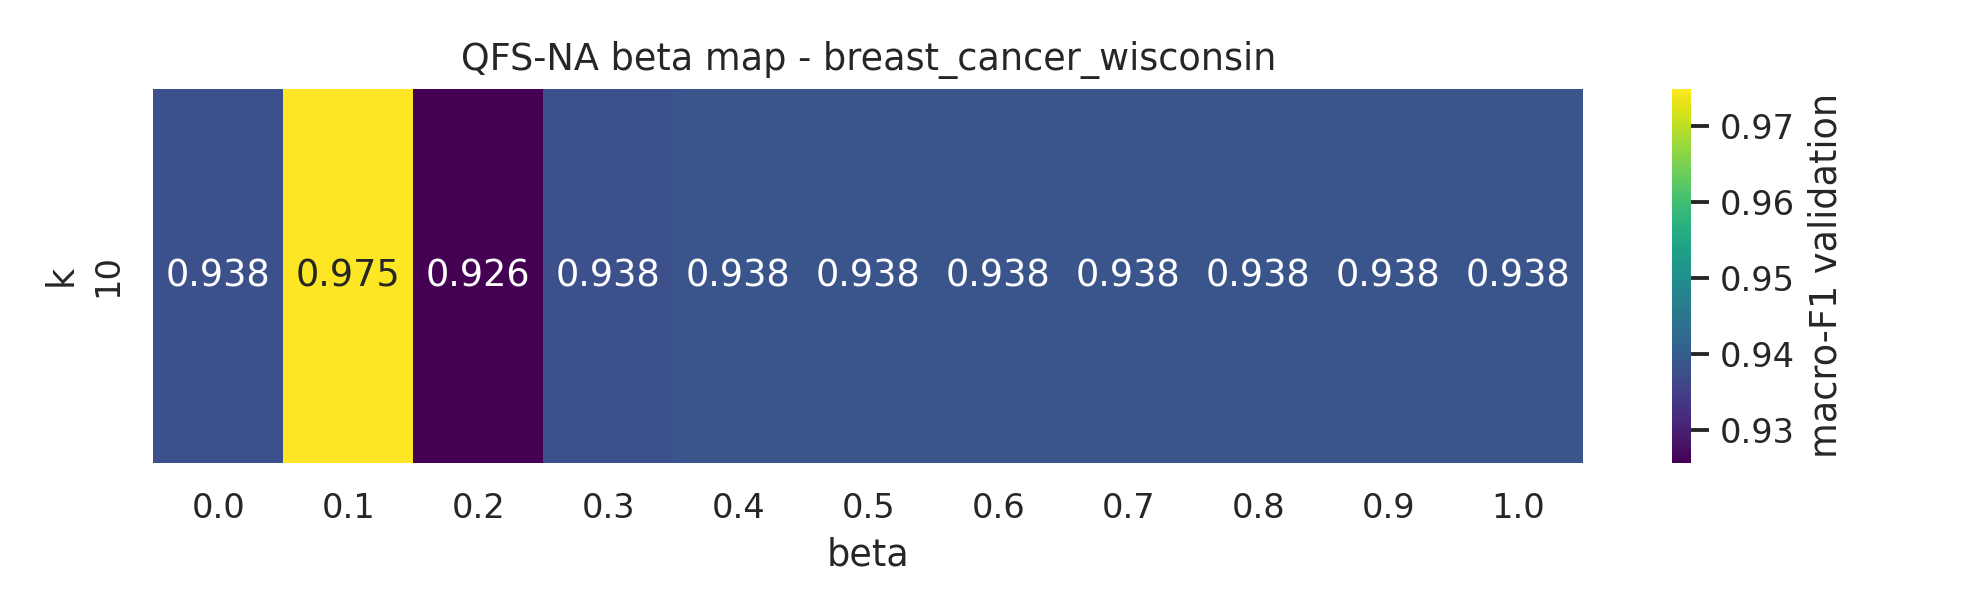

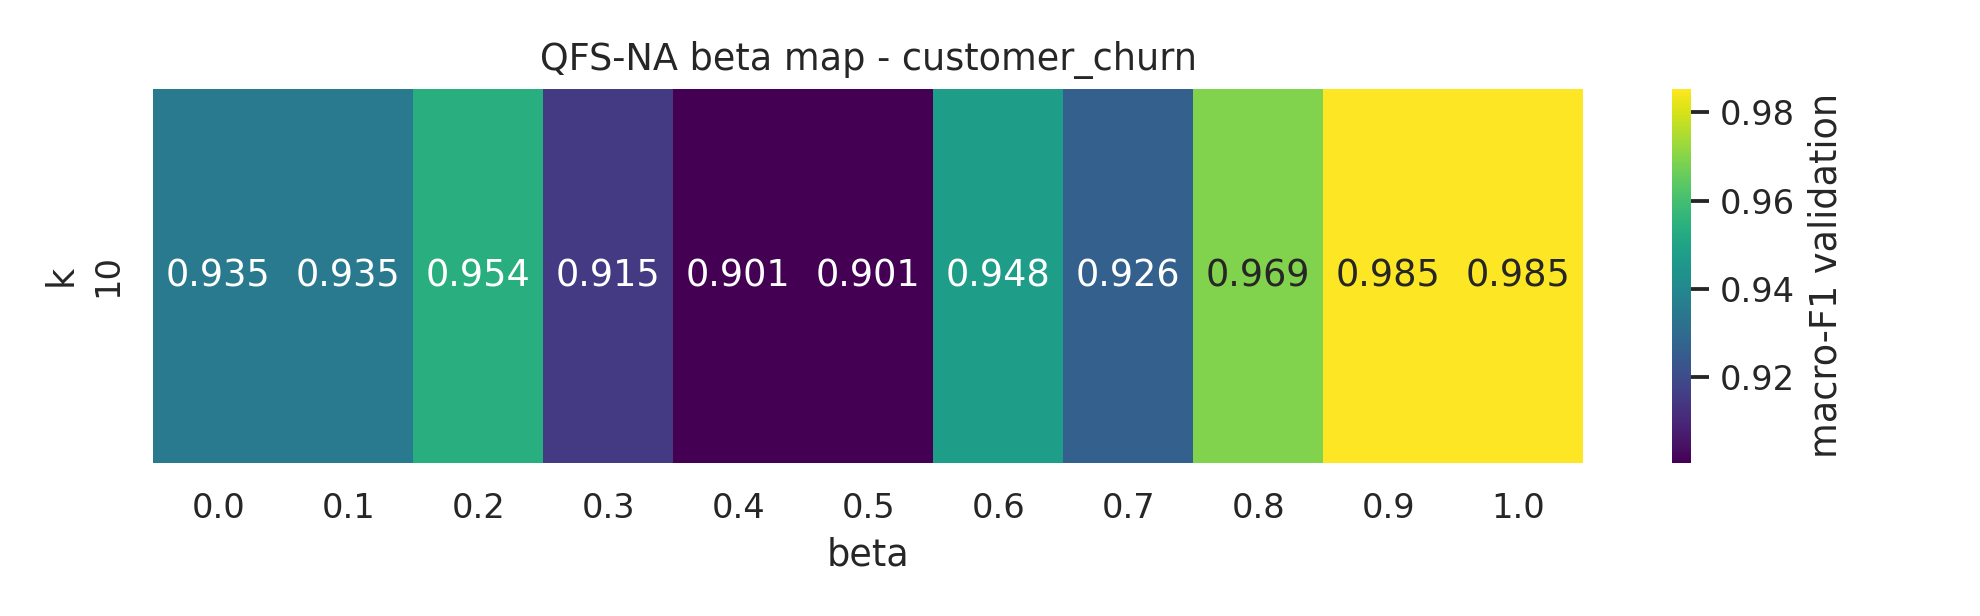

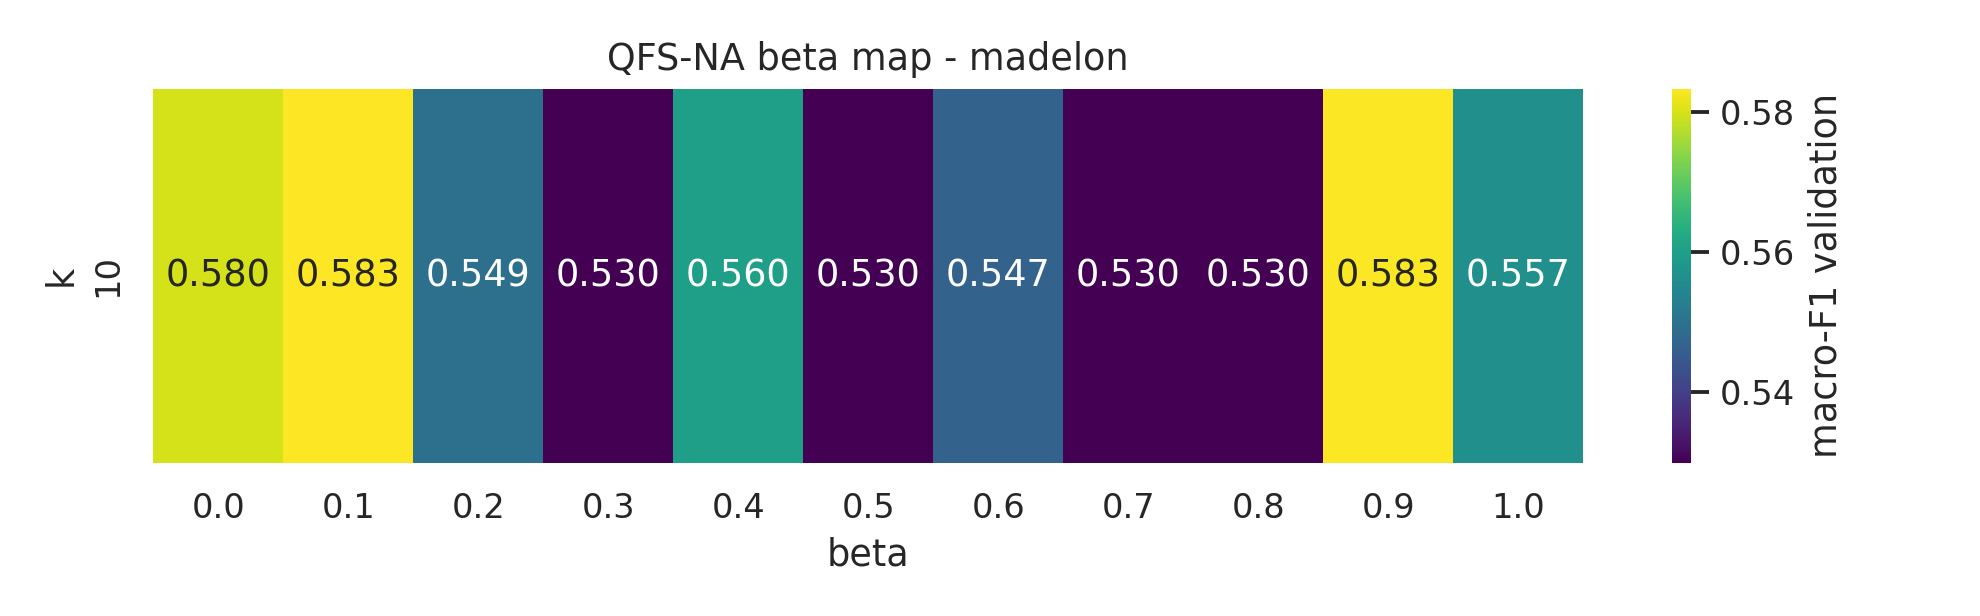

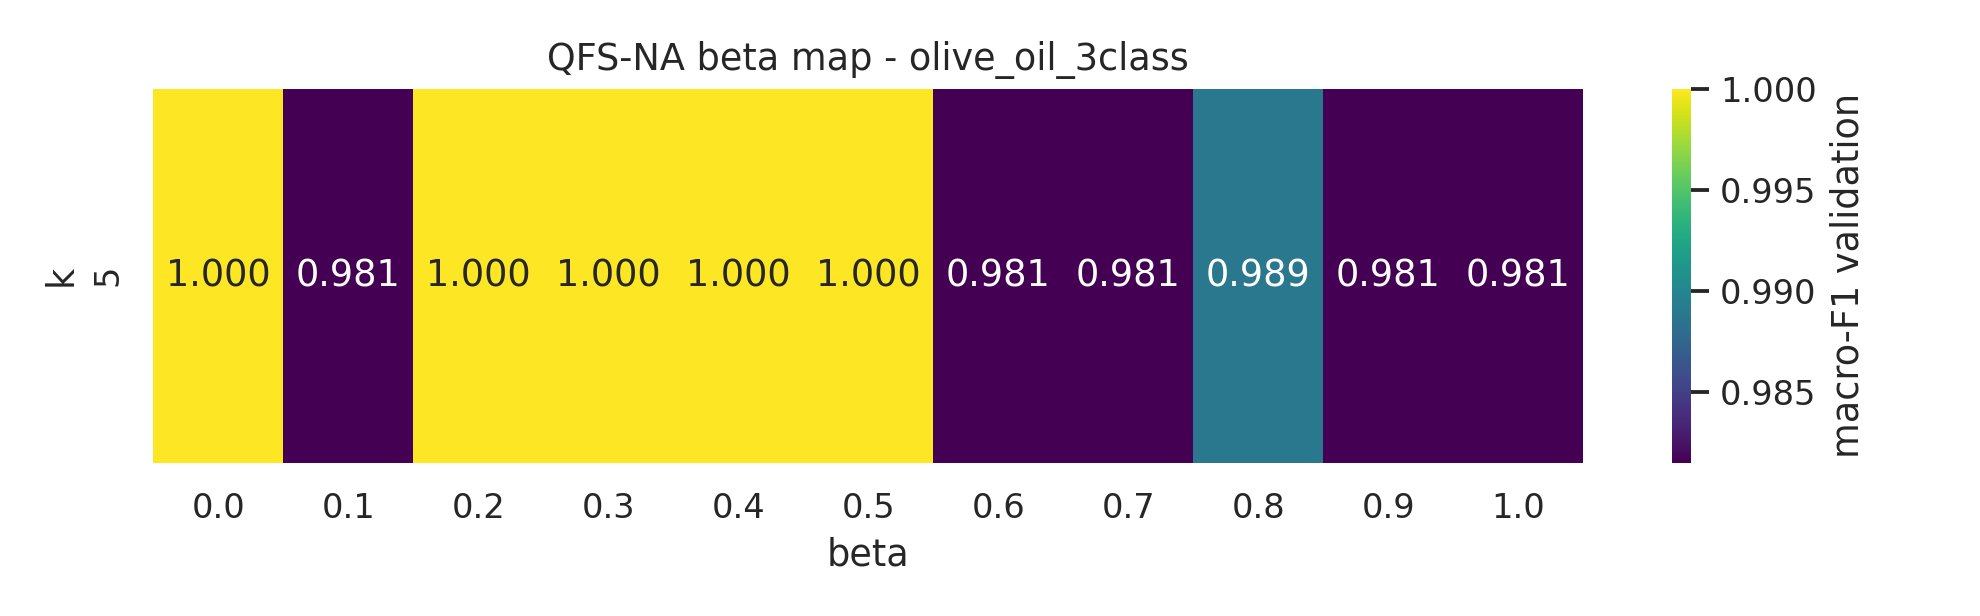

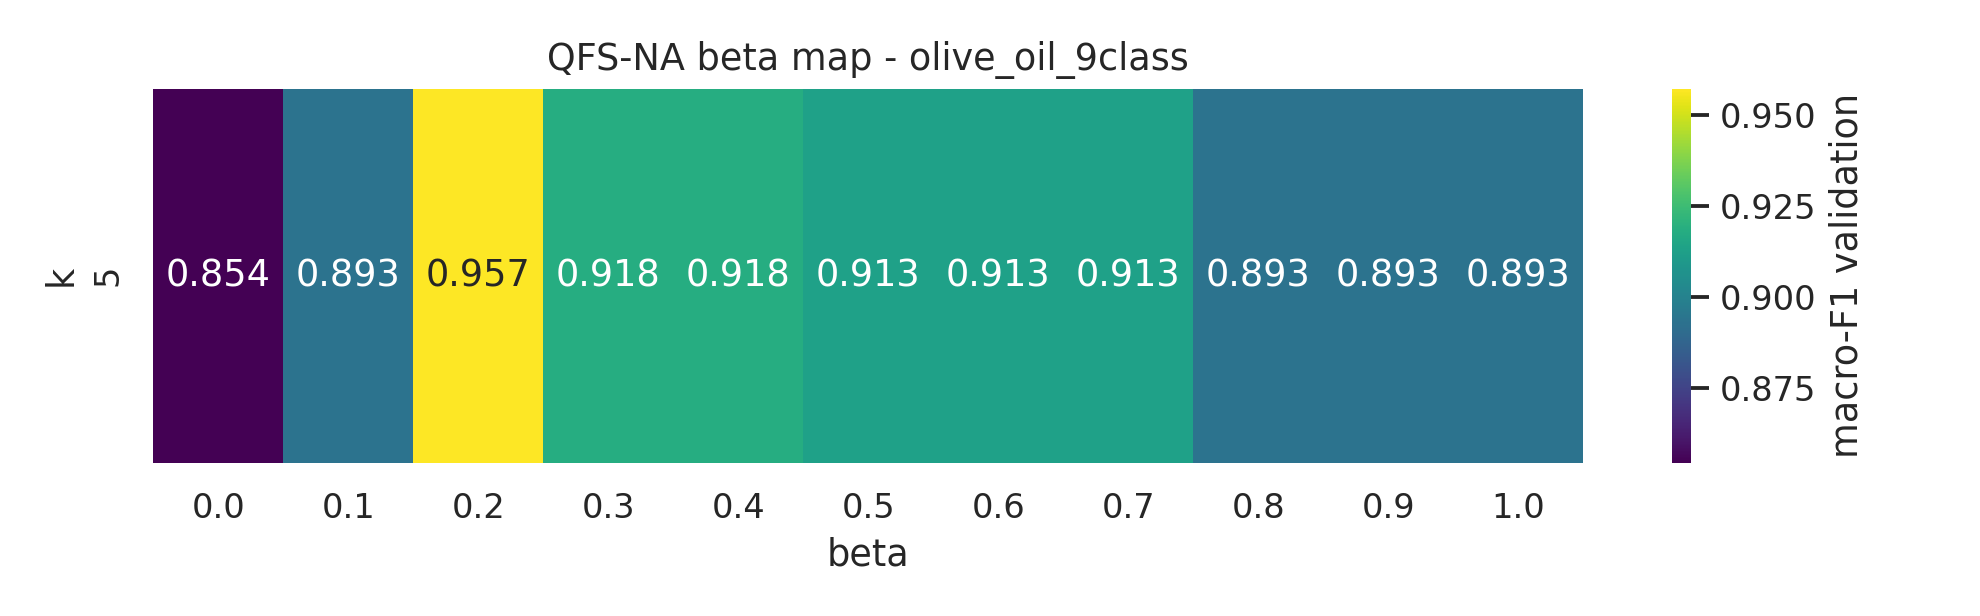

In [7]:
sns.set_theme(style="whitegrid", context="notebook")
for dataset, group in validation_table[validation_table["configuration"].eq("qfs_na")].groupby("dataset"):
    pivot = group.pivot_table(index="k", columns="beta", values="validation_macro_f1", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(9, 2.8))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", cbar_kws={"label": "macro-F1 validation"}, ax=ax)
    ax.set_title(f"QFS-NA beta map - {dataset}")
    ax.set_xlabel("beta")
    ax.set_ylabel("k")
    fig.tight_layout()
    png = FIG_OUT / f"qfs_beta_map_{dataset}.png"
    fig.savefig(png, dpi=220)
    fig.savefig(png.with_suffix(".pdf"))
    plt.close(fig)
    display(Image(filename=str(png), width=850))

Los mapas `beta x k` quedan en una sola fila porque el presupuesto operativo es unico por dataset: k=5 para Olive Oil y k=10 para los otros tres. La lectura util es horizontal: que regiones de `beta` conservan o mejoran el macro-F1 de validation antes de pasar al test final de Fase 9.

## Sintesis de Fase 8

In [8]:
resumen = selected.merge(
    quality.sort_values(["dataset", "beta"]).groupby("dataset").agg(
        hamming_min=("hamming_distance", "min"),
        hamming_mean=("hamming_distance", "mean"),
        delta_cost_min=("delta_cost_alpha05", "min"),
        delta_cost_mean=("delta_cost_alpha05", "mean"),
    ).reset_index(),
    on="dataset",
    how="left",
)
resumen.to_csv(TABLE_OUT / "qfs_phase8_summary.csv", index=False)
display(resumen)

print("Artefactos principales:")
print(f"- {TABLE_OUT / 'qfs_preselection_summary.csv'}")
print(f"- {TABLE_OUT / 'qfs_validation_results.csv'}")
print(f"- {TABLE_OUT / 'qfs_selected_all.csv'}")
print(f"- {TABLE_OUT / 'qfs_embedding_error.csv'}")
print(f"- {TABLE_OUT / 'qfs_phase8_summary.csv'}")

,dataset,configuration,alpha,beta,k,n_features,selected_features,validation_macro_f1,validation_balanced_accuracy,validation_accuracy,fit_seconds,hamming_min,hamming_mean,delta_cost_min,delta_cost_mean
0,breast_cancer_wisconsin,qfs_na,0.500000,0.1,10,10,texture_worst|concave_points_mean|radius_mean|...,0.974941,0.974941,0.976471,0.267125,2,3.818182,-4.398522,4.392943
1,breast_cancer_wisconsin,qfs_oracle_mucke,0.953125,NaN,10,10,concave_points_worst|texture_worst|concave_poi...,0.925699,0.931014,0.929412,0.267410,2,3.818182,-4.398522,4.392943
2,customer_churn,qfs_na,0.500000,0.9,10,10,age|support_calls|payment_delay|total_spend|ge...,0.985347,0.987242,0.985558,1.046335,6,6.181818,0.506870,1.038114
3,customer_churn,qfs_oracle_mucke,0.875000,NaN,10,10,age|tenure|usage_frequency|support_calls|payme...,0.993113,0.994006,0.993225,1.035445,6,6.181818,0.506870,1.038114
4,madelon,qfs_na,0.500000,0.1,10,10,feat_241|feat_43|feat_205|feat_147|feat_346|fe...,0.583329,0.583333,0.583333,0.323609,2,2.727273,-0.014750,0.030197
5,madelon,qfs_oracle_mucke,0.982422,NaN,10,10,feat_241|feat_43|feat_205|feat_147|feat_368|fe...,0.553333,0.553333,0.553333,0.275839,2,2.727273,-0.014750,0.030197
6,olive_oil_3class,qfs_na,0.500000,0.0,5,5,stearic|linolenic|arachidic|eicosenoic|other,1.000000,1.000000,1.000000,0.248644,0,1.636364,-0.333588,0.180656
7,olive_oil_3class,qfs_oracle_mucke,0.875000,NaN,5,5,linoleic|linolenic|arachidic|eicosenoic|other,1.000000,1.000000,1.000000,0.258405,0,1.636364,-0.333588,0.180656
8,olive_oil_9class,qfs_na,0.500000,0.2,5,5,oleic|linoleic|linolenic|arachidic|other,0.957227,0.953263,0.965116,0.288412,0,2.727273,0.000000,0.958834
9,olive_oil_9class,qfs_oracle_mucke,0.750000,NaN,5,5,stearic|oleic|linolenic|arachidic|other,0.854498,0.856702,0.906977,0.230392,0,2.727273,0.000000,0.958834


Artefactos principales:
- /home/gosacar/TFG - QFS Last Chance Claude/results/tables/08_quantum/qfs_preselection_summary.csv
- /home/gosacar/TFG - QFS Last Chance Claude/results/tables/08_quantum/qfs_validation_results.csv
- /home/gosacar/TFG - QFS Last Chance Claude/results/tables/08_quantum/qfs_selected_all.csv
- /home/gosacar/TFG - QFS Last Chance Claude/results/tables/08_quantum/qfs_embedding_error.csv
- /home/gosacar/TFG - QFS Last Chance Claude/results/tables/08_quantum/qfs_phase8_summary.csv


La fase 8 deja dos candidatos por dataset para la fase 9: el QFS-NA elegido por validation y el oraculo `mucke_k`. La columna Hamming resume hasta que punto el simulador analogico y el QUBO exacto proponen los mismos atomos/variables bajo el presupuesto fijado.